# Fly Chess (Colab, v2): grafting a cortex onto the frozen MaleCNS connectome

Standalone Colab port of the **corrected** `fly-chess.ipynb` from the `fly-heaven-version-2`
branch/worktree — no local repo needed, everything downloads directly from public sources.
This is *not* the same as the repo's `fly-chess-colab.ipynb` on `master`, which ports the
original notebook and still carries the bugs this version fixes: mover-perspective Stockfish
scoring, opponent-perspective PUCT backup with pending-leaf reservations, a 4,184-move
vocabulary with distinct underpromotions, matched-step controls (C0/C1/C2) plus lesion/no-graft/
no-senses/relay-permute interventions, W/D/L match results with paired-opening confidence
intervals instead of an invented Elo fit, and atomic checkpoints with full RNG state for exact
resume.

**Before running**: `Runtime -> Change runtime type -> T4 GPU` (or better), then `Runtime ->
Run all`. Leave `MODE = "smoke"` for a first pass (~10-15 min, tiny synthetic connectome, no
big downloads) to confirm everything executes, then set `MODE = "full"` and re-run for the real
four-hour pilot against the actual 166,606-neuron MaleCNS graph (~1.1 GB one-time download).
Colab free tiers can disconnect after ~12h or on idle; set `USE_DRIVE = True` in the setup cell
first if you want checkpoints and downloads to survive a disconnect/reconnect.

flychess-hq plays out every legal move, injects each resulting board into 8,865 sensory
neurons of the frozen connectome, reads 2,129 descending/motor neurons, and ranks moves with a
**linear** map — no engine ranks the moves; it plays weakly because it only looks one move ahead
and sits on wiring that was never shaped for chess. This notebook grafts a small **trainable
cortex** onto the same frozen wiring instead: it may only *see* the board by injecting current
into fly sensory neurons, and may only *act* by injecting current into fly premotor neurons — the
move is always read out of the fly's own descending/motor population. Controls in section 3
measure how much of any strength gain is really the fly, versus the graft, versus the wiring.


In [ ]:
import os
os.environ["FLY_CHESS_MODE"] = "full" # smoke for test

In [ ]:
import subprocess
import sys

_pip = subprocess.run(
    [sys.executable, "-m", "pip", "install", "chess>=1.11.2", "zstandard", "scikit-learn", "pyarrow"],
    capture_output=True, text=True,
)
print(_pip.stdout[-2000:])
if _pip.returncode != 0:
    print(_pip.stderr[-4000:])
    # !pip (shell magic) never raises on failure, so a silent/transient install error would
    # otherwise surface several cells later as a confusing "ModuleNotFoundError: chess" instead
    # of here, where the actual cause is visible.
    raise RuntimeError("pip install failed \u2014 see the output above (often a transient network "
                        "issue in the Colab VM); re-run this cell, or Runtime -> Restart session "
                        "and Run all if it keeps failing")
import chess
import chess.engine
import chess.pgn
print(f"python-chess {chess.__version__} installed OK, with engine + pgn submodules")



python-chess 1.11.2 installed OK, with engine + pgn submodules


In [ ]:
import chess
import chess.engine
import chess.pgn
import pickle
import random
import contextlib
import fcntl
import io
import uuid
import hashlib
import json
import math
import os
import subprocess
import sys
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import zstandard
from scipy.sparse import load_npz

# Optional: mount Google Drive so downloads and checkpoints survive a runtime reset/disconnect.
# Set True, re-run this cell, and approve the access prompt.
USE_DRIVE = False
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    ROOT = Path("/content/drive/MyDrive/fly-chess-v2")
else:
    ROOT = Path("/content/fly-chess-v2")

DATA = ROOT / "data"
RAW = DATA / "malecns-v1.0"
CHESS_DATA = DATA / "fly-chess"
RUNS = ROOT / "runs" / "fly-chess-v2"
for _d in (RAW, CHESS_DATA, RUNS):
    _d.mkdir(parents=True, exist_ok=True)

# "smoke" runs every section in minutes on a small synthetic connectome, to check the notebook
# end to end without a big download. "full" uses the real MaleCNS graph and the multi-hour
# budget. Colab has no separate process to launch this into, so just edit this line (and
# FLY_CHESS_RUN_ID below, for a fresh run) and re-run rather than setting environment variables.
MODE = os.environ.get("FLY_CHESS_MODE", "smoke")
assert MODE in ("smoke", "full")

DEVICE = torch.device(os.environ.get("FLY_CHESS_DEVICE", "cuda" if torch.cuda.is_available() else "cpu"))
if DEVICE.type != "cuda":
    print("WARNING: no GPU. Runtime -> Change runtime type -> GPU, then Runtime -> Restart session.")
SEED = 0
random.seed(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)


def sha256(path):
    digest = hashlib.sha256()
    with open(path, "rb") as handle:
        while block := handle.read(8 * 1024 * 1024):
            digest.update(block)
    return digest.hexdigest()


def sh(*args, cwd=ROOT):
    args = [str(a) for a in args]
    print("$", " ".join(args), flush=True)
    with subprocess.Popen(args, cwd=cwd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True) as process:
        for line in process.stdout:
            print(line, end="", flush=True)
    process.wait()
    if process.returncode:
        raise subprocess.CalledProcessError(process.returncode, args)


INK, INK_2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "axes.titlesize": 11,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.edgecolor": AXIS,
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": GRID, "grid.linewidth": 0.8, "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK_2, "ytick.labelcolor": INK_2, "legend.frameon": False,
    "lines.linewidth": 2, "figure.dpi": 110,
})
print(f"mode={MODE}  device={DEVICE}  torch={torch.__version__}  python-chess={chess.__version__}")


mode=full  device=cuda  torch=2.11.0+cu128  python-chess=1.11.2


## Run identity and recovery

Caches are versioned; legacy checkpoints are never loaded. Checkpoints include random states,
configuration identity and elapsed active compute. A stop request is honored between operations;
a hard interruption can lose work since the last checkpoint. CUDA bitwise reproducibility and
safe suspend recovery are not guaranteed.


In [ ]:
EXPERIMENT_VERSION = 2
RUN_ID = os.environ.get("FLY_CHESS_RUN_ID", f"{MODE}-{time.strftime('%Y%m%d-%H%M%S')}-{uuid.uuid4().hex[:8]}")
assert Path(RUN_ID).name == RUN_ID and RUN_ID not in (".", "..")
RUN_DIR = RUNS / RUN_ID
RUN_DIR.mkdir(parents=True, exist_ok=True)
RUN_START = time.monotonic()
TOTAL_BUDGET = 240 * 60 if MODE == "full" else 15 * 60

class RunPaused(Exception):
    pass


def atomic_json(path, value):
    path = Path(path)
    temporary = path.with_suffix(path.suffix + ".tmp")
    with temporary.open("w") as handle:
        json.dump(value, handle, indent=2, allow_nan=False)
        handle.flush()
        os.fsync(handle.fileno())
    os.replace(temporary, path)


def check_stop():
    if (RUN_DIR / "STOP").exists():
        raise RunPaused("Stop requested; remove STOP before resuming")


@contextlib.contextmanager
def writer_lock():
    if globals().get("RUN_LOCK_HANDLE") is not None:
        yield
        return
    with (RUN_DIR / "writer.lock").open("a") as handle:
        try:
            fcntl.flock(handle, fcntl.LOCK_EX | fcntl.LOCK_NB)
        except BlockingIOError:
            raise RuntimeError("Another writer owns this run")
        try:
            yield
        finally:
            fcntl.flock(handle, fcntl.LOCK_UN)


def rng_state(sampler):
    return {"python": random.getstate(), "numpy": np.random.get_state(),
            "sampler": sampler.get_state(), "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if DEVICE.type == "cuda" else None}


def restore_rng(state, sampler):
    random.setstate(state["python"])
    np.random.set_state(state["numpy"])
    sampler.set_state(state["sampler"])
    torch.set_rng_state(state["torch"].cpu())
    if state["cuda"] is not None and DEVICE.type == "cuda":
        torch.cuda.set_rng_state_all([s.cpu() for s in state["cuda"]])


def save_checkpoint(path, state):
    path = Path(path)
    temporary = path.with_suffix(".tmp")
    with temporary.open("wb") as handle:
        torch.save(state, handle)
        handle.flush()
        os.fsync(handle.fileno())
    if path.exists():
        os.replace(path, path.with_suffix(".previous.pt"))
    os.replace(temporary, path)


def load_checkpoint(path, identity):
    path = Path(path)
    candidates = [path, path.with_suffix(".previous.pt")]
    for candidate in candidates:
        if not candidate.exists():
            continue
        try:
            # Only local checkpoints created by this notebook are accepted.
            state = torch.load(candidate, map_location="cpu", weights_only=False)
        except (EOFError, RuntimeError, OSError, pickle.UnpicklingError):
            continue
        if state["identity"] != identity:
            raise ValueError("Checkpoint manifest mismatch; create a new run")
        return state
    if any(p.exists() for p in candidates):
        raise RuntimeError("No valid checkpoint remains")
    return None


def event(record):
    with (RUN_DIR / "events.jsonl").open("a") as handle:
        handle.write(json.dumps(record, allow_nan=False) + "\n")
        handle.flush()

print("run", RUN_ID)

# Hold exclusive ownership across setup, calibration, training and evaluation.
RUN_LOCK_HANDLE = (RUN_DIR / "writer.lock").open("a")
try:
    fcntl.flock(RUN_LOCK_HANDLE, fcntl.LOCK_EX | fcntl.LOCK_NB)
except BlockingIOError:
    RUN_LOCK_HANDLE.close()
    RUN_LOCK_HANDLE = None
    raise RuntimeError("Another kernel owns this run")


run full-20260913-072724-45b8c335


## Board and move contract

Values are for the side to move: loss 0, draw 0.5, win 1. Labels from the Lichess
engine cache are White-perspective scores; Black scores are inverted before conversion.
The engine-derived sigmoid is an outcome proxy, not a calibrated empirical win probability.
The move vocabulary has 4,184 classes and keeps underpromotions distinct.


In [ ]:
PIECE_INDEX = {chess.PAWN: 0, chess.KNIGHT: 1, chess.BISHOP: 2, chess.ROOK: 3, chess.QUEEN: 4, chess.KING: 5}
N_FEATURES = 780
PROMOTION_PAIRS = [(frm, to) for frm in range(48, 56) for to in range(56, 64)
                   if abs(chess.square_file(frm) - chess.square_file(to)) <= 1]
PROMOTION_KEYS = [(frm, to, piece) for frm, to in PROMOTION_PAIRS
                  for piece in (chess.QUEEN, chess.ROOK, chess.BISHOP, chess.KNIGHT)]
PROMOTION_INDEX = {key: 4096 + i for i, key in enumerate(PROMOTION_KEYS)}
N_MOVES = 4096 + len(PROMOTION_KEYS)
assert N_MOVES == 4184


def perspective_square(square, us):
    return square if us == chess.WHITE else chess.square_mirror(square)


def encode_board(board):
    x = np.zeros(N_FEATURES, dtype=np.float32)
    us, them = board.turn, not board.turn
    for square, piece in board.piece_map().items():
        sq = perspective_square(square, us)
        offset = 0 if piece.color == us else 6
        x[(offset + PIECE_INDEX[piece.piece_type]) * 64 + sq] = 1.0
    base = 768
    x[base + 0] = board.has_kingside_castling_rights(us)
    x[base + 1] = board.has_queenside_castling_rights(us)
    x[base + 2] = board.has_kingside_castling_rights(them)
    x[base + 3] = board.has_queenside_castling_rights(them)
    if board.ep_square is not None:
        ep = perspective_square(board.ep_square, us)
        x[base + 4 + chess.square_file(ep)] = 1.0
    return x


def move_index(move, us):
    frm = perspective_square(move.from_square, us)
    to = perspective_square(move.to_square, us)
    return PROMOTION_INDEX[(frm, to, move.promotion)] if move.promotion else frm * 64 + to


def legal_move_table(board):
    """{move_index: [legal chess.Move, ...]} for every legal move, mirrored to the mover's frame."""
    us = board.turn
    table = {}
    for move in board.legal_moves:
        table.setdefault(move_index(move, us), []).append(move)
    return table


def index_to_move(idx, board):
    candidates = legal_move_table(board)[int(idx)]
    assert len(candidates) == 1, "Move vocabulary collision"
    return candidates[0]


def terminal_value(board):
    outcome = board.outcome(claim_draw=True)
    if outcome is None:
        return None
    return 0.5 if outcome.winner is None else float(outcome.winner == board.turn)


def source_value(board, cp=None, mate=None):
    terminal = terminal_value(board)
    if terminal is not None:
        return terminal
    sign = 1 if board.turn == chess.WHITE else -1
    if mate is not None:
        if mate == 0:
            raise ValueError("Nonterminal zero-distance mate score")
        return float(sign * mate > 0)
    return float(torch.sigmoid(torch.tensor(0.00368208 * sign * cp, dtype=torch.float64)))


def position_key(board):
    return hashlib.sha256(encode_board(board).astype(np.uint8).tobytes()).hexdigest()


def partition(board):
    bucket = int(position_key(board)[:16], 16) % 100
    return "train" if bucket < 90 else "validation" if bucket < 95 else "test"


def mask_logits(logits, boards):
    mask = torch.full_like(logits, -torch.inf)
    for i, board in enumerate(boards):
        indices = list(legal_move_table(board))
        mask[i, indices] = 0
    return logits + mask


In [ ]:
def stream_zst_lines(url):
    """Yields raw lines from a remote .zst file without downloading it whole."""
    dctx = zstandard.ZstdDecompressor()
    with urllib.request.urlopen(url) as response, dctx.stream_reader(response) as reader:
        buffer = b""
        while True:
            chunk = reader.read(1 << 20)
            if not chunk:
                break
            buffer += chunk
            *lines, buffer = buffer.split(b"\n")
            yield from lines
        if buffer:
            yield buffer


## Versioned data ingestion

The Lichess export selects its deepest evaluation and first principal variation. It uses
board-aware UCI_Chess960 castling parsing. Raw labels, search depth, source perspective,
accepted/rejected counts and content hashes are saved. Identical model inputs share a split.
This establishes position separation, not source-game separation.

Provenance: [export format](https://database.lichess.org/#evals),
[White-perspective score normalization](https://github.com/lichess-org/lila/blob/master/ui/lib/src/ceval/protocol.ts).


In [ ]:
EVAL_URL = "https://database.lichess.org/lichess_db_eval.jsonl.zst"
N_POSITIONS = int(os.environ.get("FLY_CHESS_POSITIONS", 2000 if MODE == "smoke" else 1_000_000))
MIN_DEPTH = 10 if MODE == "smoke" else 14
positions_path = CHESS_DATA / f"positions-v2-{MODE}-{N_POSITIONS}.npz"


def ingest_positions(lines, limit, min_depth):
    rows, seen, rejected = [], set(), {}
    for raw in lines:
        check_stop()
        try:
            row = json.loads(raw)
            board = chess.Board(row["fen"])
            if not board.is_valid() or terminal_value(board) is not None:
                raise ValueError("invalid_or_terminal")
            fen = board.fen(en_passant="fen")
            if fen in seen:
                continue
            best = max(row["evals"], key=lambda e: (e["depth"], e.get("knodes", 0)))
            if best["depth"] < min_depth:
                continue
            pv = best["pvs"][0]
            move = board.parse_uci(pv["line"].split()[0])
            if move not in board.legal_moves:
                raise ValueError("illegal_label")
            value = source_value(board, pv.get("cp"), pv.get("mate"))
            rows.append((fen, move.uci(), value, best["depth"], pv.get("cp", 0),
                         pv.get("mate", 0), "mate" in pv, position_key(board), partition(board)))
            seen.add(fen)
        except (ValueError, KeyError, IndexError, TypeError) as exc:
            reason = type(exc).__name__ + ":" + str(exc)[:100]
            rejected[reason] = rejected.get(reason, 0) + 1
        if len(rows) >= limit:
            break
    return rows, rejected


if not positions_path.exists():
    with contextlib.closing(stream_zst_lines(EVAL_URL)) as lines:
        rows, rejected = ingest_positions(lines, N_POSITIONS, MIN_DEPTH)
    columns = list(zip(*rows))
    np.savez_compressed(positions_path, fen=np.array(columns[0]), move=np.array(columns[1]),
                        value=np.array(columns[2], np.float32), depth=np.array(columns[3]),
                        raw_cp=np.array(columns[4]), raw_mate=np.array(columns[5]),
                        is_mate=np.array(columns[6]), key=np.array(columns[7]), split=np.array(columns[8]))
    atomic_json(positions_path.with_suffix(".json"), {"schema": 2, "url": EVAL_URL,
                "perspective": "white", "accepted": len(rows), "rejected": rejected,
                "sha256": sha256(positions_path)})
pin = json.loads(positions_path.with_suffix(".json").read_text())
assert pin["schema"] == 2 and pin["sha256"] == sha256(positions_path), "Dataset cache integrity mismatch"
positions = np.load(positions_path, allow_pickle=False)
fens, labels_uci, values = positions["fen"], positions["move"], positions["value"]
train_idx = np.flatnonzero(positions["split"] == "train")
validation_idx = np.flatnonzero(positions["split"] == "validation")
test_idx = np.flatnonzero(positions["split"] == "test")
assert all(len(x) for x in (train_idx, validation_idx, test_idx))
for idx in np.random.RandomState(SEED).choice(len(fens), min(1000, len(fens)), replace=False):
    board = chess.Board(str(fens[idx]))
    for move in board.legal_moves:
        assert index_to_move(move_index(move, board.turn), board) == move
print("positions", len(fens), "train/validation/test", *map(len, (train_idx, validation_idx, test_idx)))


positions 1000000 train/validation/test 899922 50046 50032


In [ ]:
PUZZLE_URL = "https://database.lichess.org/lichess_db_puzzle.csv.zst"
N_PUZZLES = 100 if MODE == "smoke" else 5_000
puzzles_path = CHESS_DATA / f"puzzles-{MODE}.csv"

if not puzzles_path.exists():
    import csv
    import io

    gen = stream_zst_lines(PUZZLE_URL)
    rows = []
    try:
        header = next(gen).decode()
        for raw in gen:
            rows.append(raw.decode())
            if len(rows) >= N_PUZZLES:
                break
    finally:
        gen.close()
    puzzles_path.write_text(header + "\n" + "\n".join(rows) + "\n")

puzzles = pd.read_csv(puzzles_path)
print(f"{len(puzzles):,} puzzles, rating {puzzles['Rating'].min()}-{puzzles['Rating'].max()}")


def puzzle_training_overlap(row, training_keys):
    board = chess.Board(row["FEN"])
    for ply, move in enumerate(row["Moves"].split()):
        if ply % 2 == 1 and position_key(board) in training_keys:
            return True
        board.push_uci(move)
    return False


5,000 puzzles, rating 399-3177


In [ ]:
import tarfile

STOCKFISH_DIR = CHESS_DATA / "stockfish"
STOCKFISH_BIN = STOCKFISH_DIR / "stockfish"
STOCKFISH_URL = "https://github.com/official-stockfish/Stockfish/releases/download/sf_19/stockfish-linux-x86-64-universal.tar.gz"
STOCKFISH_LOCK = STOCKFISH_DIR / "source.lock.json"

STOCKFISH_DIR.mkdir(parents=True, exist_ok=True)
if not STOCKFISH_BIN.exists():
    archive = STOCKFISH_DIR / "stockfish.tar.gz"
    print(f"Downloading {STOCKFISH_URL}", flush=True)
    urllib.request.urlretrieve(STOCKFISH_URL, archive)
    digest = sha256(archive)
    # The release also ships its own source tree, which includes docs like wiki/Stockfish-FAQ.md —
    # match the exact binary name (the asset's own filename, minus .tar.gz), not just a substring.
    expected_name = Path(STOCKFISH_URL).name.removesuffix(".tar.gz")
    with tarfile.open(archive) as tar:
        member = next(m for m in tar.getmembers() if m.isfile() and Path(m.name).name == expected_name)
        member.name = "stockfish"
        tar.extract(member, STOCKFISH_DIR, filter="data")
    archive.unlink()
    STOCKFISH_BIN.chmod(0o755)
    STOCKFISH_LOCK.write_text(json.dumps({"url": STOCKFISH_URL, "sha256": digest}, indent=2))
    print("pinned Stockfish sha256", digest)
else:
    pin = json.loads(STOCKFISH_LOCK.read_text())["sha256"]
    # Re-deriving from the extracted binary isn't meaningful (tar strips metadata); trust the pin
    # recorded at download time and only assert the binary still runs.
    print("Stockfish already present, pinned sha256", pin)

STOCKFISH_BINARY_SHA = sha256(STOCKFISH_BIN)
engine = chess.engine.SimpleEngine.popen_uci(str(STOCKFISH_BIN))
ENGINE_ID = dict(engine.id)
ENGINE_OPTIONS = {name: {"min": opt.min, "max": opt.max, "default": opt.default}
                  for name, opt in engine.options.items() if name in ("UCI_Elo", "Skill Level")}
engine.quit()
print("Stockfish", ENGINE_ID, STOCKFISH_BINARY_SHA)


pinned Stockfish sha256 9defc0d4e55d49c65a6d042f3e571a39fcea499ade6dbe741b53b8c65e03611f
Stockfish {'name': 'Stockfish 19', 'author': 'the Stockfish developers (see AUTHORS file)'} 0f83d24cc46d2c66c60f16001af5444873bc112b7d028594513426894c12da19


## Frozen fly and interface checks

Full mode uses the measured graph. Smoke mode uses a small signed synthetic graph to exercise
the complete pipeline quickly on CPU, and makes no biological or chess-strength claims.
Calibration and relay probes use training positions only. The motor sensitivity probe holds
board state fixed. The optional spiking comparison is disabled because the legacy identical-input
comparison is invalid.


In [ ]:
USE_REAL_GRAPH = MODE == "full" or os.environ.get("FLY_CHESS_REAL_GRAPH") == "1"
if USE_REAL_GRAPH:
    GRAPH_DIR = DATA / "connectome"
    GRAPH_DIR.mkdir(parents=True, exist_ok=True)
    GRAPH_PATH = GRAPH_DIR / "full-graph.npz"
    NODES_PATH = GRAPH_DIR / "full-nodes.npz"

    # Same public MaleCNS v1.0 source fly-heaven's fruitless and fly-wirehead projects pin (CC BY 4.0).
    MALECNS_SOURCES = {
        "annotations.feather": {
            "url": "https://storage.googleapis.com/flyem-male-cns/v1.0/connectome-data/flat-connectome/body-annotations-male-cns-v1.0-minconf-0.5.feather",
            "bytes": 14483314,
            "sha256": "2177e246113e4cfbf1e7772ec37c6da1955ff22e8063d0b1f833101f99a9a3b2",
        },
        "neurotransmitters.feather": {
            "url": "https://storage.googleapis.com/flyem-male-cns/v1.0/connectome-data/flat-connectome/body-neurotransmitters-male-cns-v1.0.feather",
            "bytes": 43282834,
            "sha256": "95c9289220663abeb3409f3ad9e5a7f8a53f8093f5139d15502cd08da8879621",
        },
        "edges.feather": {
            "url": "https://storage.googleapis.com/flyem-male-cns/v1.0/connectome-data/flat-connectome/connectome-weights-male-cns-v1.0-minconf-0.5.feather",
            "bytes": 1051241946,
            "sha256": "e35da783d1c686b2b58b3b87cd6a403ae43bfcfba8bff28e08ef752c1a56afc1",
        },
    }
    for name, info in MALECNS_SOURCES.items():
        path = RAW / name
        if not path.exists():
            print(f"Downloading {name} ({info['bytes'] / 1e6:,.0f} MB)...", flush=True)
            partial = path.with_suffix(".partial")
            urllib.request.urlretrieve(info["url"], partial)
            partial.replace(path)
        digest = sha256(path)
        assert digest == info["sha256"], f"Checksum mismatch: {name}"
        print(f"verified  {name:27s} {path.stat().st_size / 1e6:>8,.1f} MB")

    if not NODES_PATH.exists():
        import pyarrow as pa
        import pyarrow.compute as pc
        import pyarrow.feather as feather
        from scipy.sparse import csr_matrix, save_npz

        print("Building the connectome graph (fruitless's own recipe)...", flush=True)
        started = time.perf_counter()
        rows = feather.read_table(RAW / "annotations.feather").to_pylist()
        rows = sorted((r for r in rows if r["superclass"] and "tbc" not in r["superclass"]), key=lambda r: r["bodyId"])
        ids = np.array([r["bodyId"] for r in rows], dtype=np.int64)

        nt_table = feather.read_table(RAW / "neurotransmitters.feather", columns=["body", "consensus_nt"])
        nt_table = nt_table.filter(pc.is_in(nt_table["body"], pa.array(ids)))
        nts = dict(zip(nt_table["body"].to_pylist(), nt_table["consensus_nt"].to_pylist()))
        # Assumed fast signs, not measured receptor-specific physiology. Others get zero fast weight.
        signs = np.array([{"acetylcholine": 1, "gaba": -1, "glutamate": -1}.get(nts.get(int(i)), 0) for i in ids], dtype=np.int8)

        source = pa.memory_map(str(RAW / "edges.feather"))
        reader = pa.ipc.open_file(source)
        pre, post, weight = [], [], []
        for b in range(reader.num_record_batches):
            t = pa.Table.from_batches([reader.get_batch(b)])
            t = t.filter(pc.and_(pc.is_in(t["body_pre"], pa.array(ids)), pc.is_in(t["body_post"], pa.array(ids))))
            pre.append(np.searchsorted(ids, t["body_pre"].to_numpy()).astype(np.int32))
            post.append(np.searchsorted(ids, t["body_post"].to_numpy()).astype(np.int32))
            weight.append(t["weight"].to_numpy().astype(np.float32))
            if b % 400 == 0:
                print(f"  edge batch {b + 1}/{reader.num_record_batches}", flush=True)
        pre, post, weight = map(np.concatenate, (pre, post, weight))
        graph = csr_matrix((weight, (pre, post)), shape=(len(ids), len(ids)))
        graph.sort_indices()
        save_npz(GRAPH_PATH, graph)
        np.savez(NODES_PATH, ids=ids, signs=signs)
        print(f"{len(ids):,} neurons, {graph.nnz:,} edges built in {time.perf_counter() - started:.0f} s")

    nodes = np.load(NODES_PATH)
    ids, base_signs = nodes["ids"], nodes["signs"]
    W = load_npz(GRAPH_PATH)  # CSR, rows = presynaptic, values = synapse counts
    N_NEURONS = W.shape[0]
    assert (N_NEURONS, W.nnz) == (166_606, 25_574_615), "Graph differs from the reference build"

    ann = (pd.read_feather(RAW / "annotations.feather", columns=["bodyId", "superclass", "class", "type"])
           .set_index("bodyId").reindex(ids))

    SENSORY_IDX = np.nonzero(ann["superclass"].isin(["cb_sensory", "ol_sensory"]).values)[0]
    MOTOR_IDX = np.nonzero(ann["superclass"].isin(["descending_neuron", "cb_motor", "vnc_motor"]).values)[0]
    assert len(SENSORY_IDX) == 10_966 and len(MOTOR_IDX) == 2_129
    print(f"sensory {len(SENSORY_IDX):,}  ·  DN+motor {len(MOTOR_IDX):,}  ·  total {N_NEURONS:,}")

else:
    from scipy.sparse import csr_matrix
    N_NEURONS = 384
    ids = np.arange(N_NEURONS)
    base_signs = np.where(np.arange(N_NEURONS) % 5 == 0, -1, 1).astype(np.float32)
    sensory_count = 128
    SENSORY_IDX = np.arange(sensory_count)
    MOTOR_IDX = np.arange(320, 384)
    generator = np.random.RandomState(SEED)
    pre = generator.randint(0, N_NEURONS, 4000)
    post = generator.randint(0, N_NEURONS, 4000)
    W = csr_matrix((generator.randint(3, 12, 4000).astype(np.float32), (pre, post)),
                   shape=(N_NEURONS, N_NEURONS))
    ann = pd.DataFrame({"superclass": ["cb_sensory"] * 128 + ["central"] * 192 + ["cb_motor"] * 64,
                        "class": [""] * N_NEURONS})
print("graph", W.shape, W.nnz)


verified  annotations.feather             14.5 MB
verified  neurotransmitters.feather       43.3 MB
verified  edges.feather                1,051.2 MB
Building the connectome graph (fruitless's own recipe)...
  edge batch 1/2318
  edge batch 401/2318
  edge batch 801/2318
  edge batch 1201/2318
  edge batch 1601/2318
  edge batch 2001/2318
166,606 neurons, 25,574,615 edges built in 70 s
sensory 10,966  ·  DN+motor 2,129  ·  total 166,606
graph (166606, 166606) 25574615


In [ ]:
EDGE_MIN_SYNAPSES = 3  # picked below in the Phase-0 benchmark; kept ≥ here so later cells still run standalone


def build_signed_transpose(W, signs, min_synapses):
    """Wt[post, pre] = sign(pre) * synapse_count, thresholded and row-normalised (row = post)."""
    keep = W.data >= min_synapses
    pre = np.repeat(np.arange(W.shape[0]), np.diff(W.indptr))[keep]
    post = W.indices[keep]
    weight = (W.data[keep] * signs[pre]).astype(np.float32)
    row_norm = np.bincount(post, weights=np.abs(weight), minlength=W.shape[0])
    row_norm = np.maximum(row_norm, 1.0)
    weight = (weight / row_norm[post]).astype(np.float32)
    indices = torch.tensor(np.stack([post, pre]), dtype=torch.long)
    values = torch.tensor(weight)
    return torch.sparse_coo_tensor(indices, values, (W.shape[0], W.shape[0])).coalesce(), int(keep.sum())


Wt, n_edges_kept = build_signed_transpose(W, base_signs, EDGE_MIN_SYNAPSES)
Wt = Wt.to(DEVICE)
print(f"kept {n_edges_kept:,} / {W.nnz:,} edges at ≥{EDGE_MIN_SYNAPSES} synapses "
      f"({n_edges_kept / W.nnz:.0%}), {W.data[W.data >= EDGE_MIN_SYNAPSES].sum() / W.data.sum():.0%} of synapse mass")


class FlyBrain(nn.Module):
    """Frozen, batched, differentiable graded-rate model of the MaleCNS connectome."""

    def __init__(self, Wt, gain, alpha):
        super().__init__()
        self.register_buffer("Wt", Wt, persistent=False)
        self.n = Wt.shape[0]
        self.gain = gain
        self.alpha = alpha

    def step(self, r, current):
        total_input = torch.sparse.mm(self.Wt, r)
        target = torch.clamp(self.gain * total_input + current, 0.0, 1.0)
        return (1 - self.alpha) * r + self.alpha * target

    def run(self, r0, current, steps):
        r = r0
        for _ in range(steps):
            r = self.step(r, current)
        return r

    def run_clamped(self, r0, current, active_mask, steps):
        """Only `active_mask` neurons update; everyone else is held at r0 (§ act-phase)."""
        r = r0
        frozen = r0
        mask = active_mask.view(-1, 1)
        for _ in range(steps):
            r = torch.where(mask, self.step(r, current), frozen)
        return r

    def active_blocks(self, active_idx):
        active_idx = np.asarray(active_idx)
        coordinate = self.Wt.coalesce()
        ij = coordinate.indices().cpu().numpy()
        vals = coordinate.values().cpu().numpy()
        lookup = np.full(self.n, -1, dtype=np.int64)
        lookup[active_idx] = np.arange(len(active_idx))
        rows, cols = lookup[ij[0]], lookup[ij[1]]
        internal = (rows >= 0) & (cols >= 0)
        external = (rows >= 0) & (cols < 0)
        def matrix(mask, col, width):
            return torch.sparse_coo_tensor(torch.tensor(np.stack([rows[mask], col[mask]])),
                   torch.tensor(vals[mask]), (len(active_idx), width)).coalesce().to(self.Wt.device)
        return matrix(internal, cols, len(active_idx)), matrix(external, ij[1], self.n)

    def run_active(self, r0, current_active, active_idx, blocks, steps):
        internal, external = blocks
        r = r0[active_idx]
        background = torch.sparse.mm(external, r0)
        for _ in range(steps):
            target = torch.clamp(self.gain * (torch.sparse.mm(internal, r) + background)
                                 + current_active, 0, 1)
            r = (1 - self.alpha) * r + self.alpha * target
        return r


/tmp/ipykernel_3015/3500693499.py:15: UserWarning: Sparse invariant checks are implicitly disabled. Memory errors (e.g. SEGFAULT) will occur when operating on a sparse tensor which violates the invariants, but checks incur performance overhead. To silence this warning, explicitly opt in or out. See `torch.sparse.check_sparse_tensor_invariants.__doc__` for guidance.  (Triggered internally at /pytorch/aten/src/ATen/Context.cpp:760.)
  return torch.sparse_coo_tensor(indices, values, (W.shape[0], W.shape[0])).coalesce(), int(keep.sum())


kept 10,517,265 / 25,574,615 edges at ≥3 synapses (41%), 84% of synapse mass


In [ ]:
def build_injection_map(sensory_idx, n_features, seed=0):
    """A fixed, disjoint feature -> sensory-neuron-group assignment (~14 neurons/feature)."""
    rng = np.random.RandomState(seed)
    order = rng.permutation(sensory_idx)
    groups = [order[i % len(order):i % len(order) + 1] for i in range(n_features)] if len(order) < n_features else np.array_split(order, n_features)
    rows = np.concatenate(groups)
    cols = np.concatenate([np.full(len(g), i) for i, g in enumerate(groups)])
    indices = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    values = torch.ones(len(rows))
    return torch.sparse_coo_tensor(indices, values, (N_NEURONS, n_features)).coalesce().to(DEVICE)


INJECT_MAP = build_injection_map(SENSORY_IDX, N_FEATURES)
INJECT_AMPLITUDE = 1.0 if USE_REAL_GRAPH else 0.3


def sensory_current(features_b_f):
    """(B, 780) board features -> (n, B) injected current."""
    return INJECT_AMPLITUDE * torch.sparse.mm(INJECT_MAP, features_b_f.t())


def empty_cache():
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


def perceive_chunked(brain_, features_np, T_p, batch=128, keep_idx=None):
    """Runs perception in GPU-sized chunks and returns a CPU array — the (n, N) state for N boards
    at once does not fit in 6 GB much past a few hundred boards. `keep_idx` restricts the returned
    rows (e.g. to a relay candidate) to save host memory too."""
    chunks = []
    for start in range(0, len(features_np), batch):
        feats = torch.tensor(features_np[start:start + batch], device=DEVICE)
        with torch.no_grad():
            r = brain_.run(torch.zeros(brain_.n, feats.shape[0], device=DEVICE), sensory_current(feats), T_p)
        chunks.append((r if keep_idx is None else r[keep_idx]).cpu().numpy())
        del feats, r
    empty_cache()
    return np.concatenate(chunks, axis=1)


T_P_GRID = ([15, 25, 40] if MODE == "full" else [10, 15]) if USE_REAL_GRAPH else [3, 5]


In [ ]:
calibration_sample = train_idx[np.random.RandomState(2).choice(len(train_idx), min(16, len(train_idx)), replace=False)]
calibration_features = torch.tensor(np.stack([encode_board(chess.Board(str(fens[i]))) for i in calibration_sample]), device=DEVICE)
calibration_rows = []
for gain in (([1.5, 2.5, 4.0] if MODE == "full" else [1.5, 2.5]) if USE_REAL_GRAPH else [0.3, 0.6]):
    for alpha in (([0.3, 0.6, 1.0] if MODE == "full" else [0.5]) if USE_REAL_GRAPH else [0.5]):
        for steps in T_P_GRID:
            check_stop()
            with torch.no_grad():
                probe = FlyBrain(Wt, gain, alpha)
                state = probe.run(torch.zeros(N_NEURONS, len(calibration_features), device=DEVICE),
                                  sensory_current(calibration_features), steps)
            activity = float((state > 0.05).float().mean())
            saturation = float((state > 0.99).float().mean())
            sensitivity = float(state[MOTOR_IDX].std(dim=1).mean())
            calibration_rows.append({"gain": gain, "alpha": alpha, "steps": steps,
                                     "activity": activity, "saturation": saturation, "sensitivity": sensitivity})
feasible = [row for row in calibration_rows if 0.01 <= row["activity"] <= 0.30 and row["saturation"] < 0.10]
assert feasible, "No feasible calibration; revise the current/gain grid before training"
best = max(feasible, key=lambda r: (r["sensitivity"], -r["steps"], -r["gain"], -r["alpha"]))
assert best["sensitivity"] > 1e-7, "No measurable motor response to board differences"
GAIN, ALPHA, T_P = best["gain"], best["alpha"], best["steps"]
brain = FlyBrain(Wt, GAIN, ALPHA)
atomic_json(RUN_DIR / "calibration.json", calibration_rows)
print("calibration", best)


calibration {'gain': 4.0, 'alpha': 0.6, 'steps': 15, 'activity': 0.0844777524471283, 'saturation': 0.024738380685448647, 'sensitivity': 0.03239430859684944}


In [ ]:
def hop_mask(seed_idx, W, exclude=None):
    v = np.zeros(W.shape[0], dtype=np.float32)
    v[seed_idx] = 1.0
    reached = (v @ W) > 0
    if exclude is not None:
        reached &= ~exclude
    return reached


hop1 = hop_mask(SENSORY_IDX, W)
hop2 = hop_mask(np.nonzero(hop1)[0], W, exclude=hop1 | np.isin(np.arange(N_NEURONS), SENSORY_IDX))
kc_mbon = ann["class"].isin(["Kenyon_Cell", "MBON"]).values
visual_proj = (ann["superclass"] == "visual_projection").values

RELAY_CANDIDATES = {
    "1-hop from sensory": np.nonzero(hop1 & ~np.isin(np.arange(N_NEURONS), SENSORY_IDX))[0],
    "2-hop from sensory": np.nonzero(hop2)[0],
    "Kenyon+MBON": np.nonzero(kc_mbon)[0],
    "visual_projection": np.nonzero(visual_proj)[0],
}
RELAY_MAX = 128 if MODE == "smoke" else 8000
# The full (n, N_PROBE) state doesn't fit in 6 GB past a few hundred boards, so §1's benchmark
# chunk size is reused here — perceive_chunked runs one chunk at a time and returns a CPU array.
N_PROBE = 100 if MODE == "smoke" else 1000
PROBE_BATCH = 16 if MODE == "smoke" else 64

probe_fens = fens[np.random.RandomState(3).choice(train_idx, size=N_PROBE)]
probe_features = np.stack([encode_board(chess.Board(f)) for f in probe_fens])
candidate_union = np.unique(np.concatenate(list(RELAY_CANDIDATES.values())))
probe_state = perceive_chunked(brain, probe_features, T_P, batch=PROBE_BATCH, keep_idx=candidate_union)
union_lookup = {int(node): i for i, node in enumerate(candidate_union)}

from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split

relay_scores = {}
for name, idx in RELAY_CANDIDATES.items():
    idx = idx[~np.isin(idx, SENSORY_IDX)]
    if len(idx) == 0:
        continue
    pick = idx if len(idx) <= RELAY_MAX else np.random.RandomState(4).choice(idx, RELAY_MAX, replace=False)
    Xtr, Xte, Ytr, Yte = train_test_split(probe_state[[union_lookup[int(node)] for node in pick]].T, probe_features, test_size=0.2, random_state=0)
    model = Ridge(alpha=1.0).fit(Xtr, Ytr)
    r2 = model.score(Xte, Yte)
    relay_scores[name] = (r2, len(pick))
    print(f"{name:20s}  n={len(pick):>6,}  held-out R²={r2:.3f}")

RELAY_NAME = max(relay_scores, key=lambda k: relay_scores[k][0])
RELAY_IDX = (RELAY_CANDIDATES[RELAY_NAME] if len(RELAY_CANDIDATES[RELAY_NAME]) <= RELAY_MAX
             else np.random.RandomState(4).choice(RELAY_CANDIDATES[RELAY_NAME], RELAY_MAX, replace=False))
print(f"\nrelay = {RELAY_NAME}, {len(RELAY_IDX):,} neurons, R²={relay_scores[RELAY_NAME][0]:.3f}")
del probe_state
empty_cache()


1-hop from sensory    n= 8,000  held-out R²=0.210
2-hop from sensory    n= 8,000  held-out R²=0.144
Kenyon+MBON           n= 4,161  held-out R²=0.045
visual_projection     n= 8,000  held-out R²=0.136

relay = 1-hop from sensory, 8,000 neurons, R²=0.210


In [ ]:
P_SIZE = 64 if MODE == "smoke" else 4000

motor_indicator = np.zeros(N_NEURONS, dtype=np.float32)
motor_indicator[MOTOR_IDX] = 1.0
synapses_onto_motor = W @ motor_indicator  # row i = total synapses from neuron i onto M
central = ~ann["superclass"].isin(["cb_sensory", "ol_sensory", "descending_neuron", "cb_motor", "vnc_motor"]).values
choices = np.flatnonzero(central & (synapses_onto_motor > 0))
PREMOTOR_IDX = choices[np.lexsort((ids[choices], -synapses_onto_motor[choices]))[:P_SIZE]]
PREMOTOR_IDX = PREMOTOR_IDX[synapses_onto_motor[PREMOTOR_IDX] > 0]
print(f"premotor P: {len(PREMOTOR_IDX):,} central neurons, "
      f"{synapses_onto_motor[PREMOTOR_IDX].min():.0f}-{synapses_onto_motor[PREMOTOR_IDX].max():.0f} synapses onto M each")

ACTIVE_MASK = torch.zeros(N_NEURONS, dtype=torch.bool, device=DEVICE)
ACTIVE_MASK[PREMOTOR_IDX] = True
ACTIVE_MASK[MOTOR_IDX] = True
T_A = 3

ACTIVE_IDX = np.flatnonzero(ACTIVE_MASK.cpu().numpy())
MOTOR_ACTIVE_IDX = np.searchsorted(ACTIVE_IDX, MOTOR_IDX)
PREMOTOR_ACTIVE_IDX = np.searchsorted(ACTIVE_IDX, PREMOTOR_IDX)


premotor P: 4,000 central neurons, 419-9677 synapses onto M each


In [ ]:
with torch.no_grad():
    fixed_features = torch.tensor(encode_board(chess.Board(str(fens[train_idx[0]])))[None], device=DEVICE)
    fixed_state = brain.run(torch.zeros(N_NEURONS, 1, device=DEVICE), sensory_current(fixed_features), T_P)
    blocks = brain.active_blocks(ACTIVE_IDX)
    directions = np.random.RandomState(5).normal(size=(len(PREMOTOR_IDX), 16 if MODE == "smoke" else 64)).astype(np.float32)
    directions /= np.linalg.norm(directions, axis=0, keepdims=True)
    delta = torch.zeros(len(ACTIVE_IDX), directions.shape[1], device=DEVICE)
    delta[PREMOTOR_ACTIVE_IDX] = torch.tensor(directions, device=DEVICE)
    baseline = fixed_state.expand(-1, directions.shape[1])
    epsilon = 1e-3
    plus = brain.run_active(baseline, epsilon * delta, ACTIVE_IDX, blocks, T_A)[MOTOR_ACTIVE_IDX]
    minus = brain.run_active(baseline, -epsilon * delta, ACTIVE_IDX, blocks, T_A)[MOTOR_ACTIVE_IDX]
    derivatives = ((plus - minus) / (2 * epsilon)).cpu().numpy()
    singular = np.linalg.svd(derivatives, compute_uv=False)
    rank = int((singular > max(1e-7, singular[0] * 0.01)).sum())
assert singular[0] > 1e-7, "No measurable premotor control of motor outputs"
atomic_json(RUN_DIR / "motor-sensitivity.json", {"rank": rank, "singular_values": singular.tolist(),
            "method": "centered directional derivatives at one fixed training board"})
print("motor directional sensitivity rank", rank)


motor directional sensitivity rank 64


In [ ]:
class CortexGraft(nn.Module):
    def __init__(self, relay_idx, premotor_idx, d_model=64, n_latents=48, n_layers=2, n_heads=4):
        super().__init__()
        self.register_buffer("relay_idx", torch.tensor(relay_idx, dtype=torch.long), persistent=False)
        self.register_buffer("premotor_idx", torch.tensor(premotor_idx, dtype=torch.long), persistent=False)
        n_relay, n_premotor = len(relay_idx), len(premotor_idx)

        self.relay_embed = nn.Embedding(n_relay, d_model)
        self.premotor_query = nn.Embedding(n_premotor, d_model)
        self.latents = nn.Parameter(torch.randn(n_latents, d_model) * 0.02)

        self.encode_in = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.self_layers = nn.ModuleList(
            nn.MultiheadAttention(d_model, n_heads, batch_first=True) for _ in range(n_layers)
        )
        self.norms = nn.ModuleList(nn.LayerNorm(d_model) for _ in range(n_layers + 1))
        self.decode_out = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
        self.current_head = nn.Linear(d_model, 1)

    def forward(self, relay_rate):
        """relay_rate: (B, n_relay) -> premotor current (B, n_premotor)."""
        B = relay_rate.shape[0]
        tokens = self.relay_embed.weight.unsqueeze(0) * relay_rate.unsqueeze(-1)  # (B, n_relay, d)
        latents = self.latents.unsqueeze(0).expand(B, -1, -1)
        latents = self.norms[0](latents + self.encode_in(latents, tokens, tokens)[0])
        for layer, norm in zip(self.self_layers, self.norms[1:]):
            latents = norm(latents + layer(latents, latents, latents)[0])
        queries = self.premotor_query.weight.unsqueeze(0).expand(B, -1, -1)
        out, _ = self.decode_out(queries, latents, latents)
        return self.current_head(out).squeeze(-1)  # (B, n_premotor)


class MoveDecoder(nn.Module):
    """Reads the fly's own DN+motor population; never sees the board or the relay directly."""

    def __init__(self, n_motor, n_moves=N_MOVES, hidden=256):
        super().__init__()
        self.policy = nn.Linear(n_motor, n_moves)
        self.value = nn.Linear(n_motor, 1)

    def forward(self, motor_rate):
        return self.policy(motor_rate), self.value(motor_rate).squeeze(-1)


class FlyChessModel(nn.Module):
    """board -> (fly sense) -> graft -> (fly act) -> policy logits, value. `brain` stays frozen."""

    def __init__(self, brain, relay_idx, premotor_idx, motor_idx, active_mask, T_p, T_a,
                 current_amplitude=2.0, **graft_kw):
        super().__init__()
        self.brain = brain
        self.graft = CortexGraft(relay_idx, premotor_idx, **graft_kw)
        self.decoder = MoveDecoder(len(motor_idx))
        self.register_buffer("relay_idx", torch.tensor(relay_idx, dtype=torch.long), persistent=False)
        self.register_buffer("premotor_idx", torch.tensor(premotor_idx, dtype=torch.long), persistent=False)
        self.register_buffer("motor_idx", torch.tensor(motor_idx, dtype=torch.long), persistent=False)
        self.register_buffer("active_mask", active_mask, persistent=False)
        self.T_p, self.T_a, self.current_amplitude = T_p, T_a, current_amplitude
        active_idx = np.flatnonzero(active_mask.cpu().numpy())
        self.register_buffer("active_idx", torch.tensor(active_idx), persistent=False)
        self.motor_active_idx = np.searchsorted(active_idx, motor_idx)
        self.premotor_active_idx = np.searchsorted(active_idx, premotor_idx)
        self.blocks = brain.active_blocks(active_idx)

    def forward(self, features, lesion_relay=False, intervention=None):
        n, B = self.brain.n, features.shape[0]
        with torch.no_grad():
            r_perceived = self.brain.run(torch.zeros(n, B, device=features.device),
                                          sensory_current(features), self.T_p)
        if intervention == "no_senses":
            r_perceived = torch.zeros_like(r_perceived)
        relay_rate = r_perceived[self.relay_idx].t()  # (B, n_relay)
        if lesion_relay:
            relay_rate = torch.zeros_like(relay_rate)  # §3 C3: sever fly->graft, keep everything else
        if intervention == "relay_permute":
            relay_rate = relay_rate.roll(1, dims=0)
        premotor_current = self.graft(relay_rate) * self.current_amplitude

        if intervention == "no_graft":
            premotor_current = torch.zeros_like(premotor_current)
        current = torch.zeros(len(self.active_idx), B, device=features.device)
        current[self.premotor_active_idx] = premotor_current.t()
        r_final = self.brain.run_active(r_perceived, current, self.active_idx, self.blocks, self.T_a)
        return self.decoder(r_final[self.motor_active_idx].t())


## Controls and matched training

C0 is a local fly/readout baseline, not an exact reproduction of the website's candidate-board
ranking. C1 has the main model's exact trainable architecture, replacing fly transformations with
fixed synthetic projections. C2 uses directed sign-class edge swaps; edge counts are preserved,
but weighted input strengths need not be. Interfaces and calibration stay fixed across C2.


In [ ]:
class FlyOnlyModel(nn.Module):
    """flychess-hq's own design: sensory injection -> frozen fly -> linear readout of M."""

    def __init__(self, brain, motor_idx, T_p):
        super().__init__()
        self.brain = brain
        self.decoder = nn.Linear(len(motor_idx), N_MOVES + 1)  # +1 column split off below for value
        self.register_buffer("motor_idx", torch.tensor(motor_idx, dtype=torch.long), persistent=False)
        self.T_p = T_p

    def forward(self, features, **_):
        n, B = self.brain.n, features.shape[0]
        with torch.no_grad():
            r = self.brain.run(torch.zeros(n, B, device=features.device), sensory_current(features), self.T_p)
        out = self.decoder(r[self.motor_idx].t())
        return out[:, :N_MOVES], out[:, N_MOVES]


In [ ]:
class SyntheticFlyInterface(nn.Module):
    def __init__(self, seed=11):
        super().__init__()
        generator = np.random.RandomState(seed)
        def projection(rows, cols, degree=14):
            ii = np.repeat(np.arange(rows), min(degree, cols))
            jj = np.concatenate([generator.choice(cols, min(degree, cols), replace=False) for _ in range(rows)])
            weights = np.full(len(ii), 1 / min(degree, cols), np.float32)
            return torch.sparse_coo_tensor(torch.tensor(np.stack([ii, jj])), torch.tensor(weights),
                                          (rows, cols)).coalesce()
        self.register_buffer("sense", projection(len(RELAY_IDX), N_FEATURES))
        self.register_buffer("background", projection(len(MOTOR_IDX), N_FEATURES))
        self.register_buffer("act", projection(len(MOTOR_IDX), len(PREMOTOR_IDX)))

    def perceive(self, features):
        return torch.sparse.mm(self.sense, features.t()).t(), torch.sparse.mm(self.background, features.t()).t()


class CortexInJar(nn.Module):
    def __init__(self):
        super().__init__()
        self.interface = SyntheticFlyInterface()
        self.graft = CortexGraft(RELAY_IDX, PREMOTOR_IDX, **GRAFT_KW)
        self.decoder = MoveDecoder(len(MOTOR_IDX))

    def forward(self, features):
        relay, background = self.interface.perceive(features)
        current = self.graft(relay) * 2.0
        motor = torch.clamp(background + torch.sparse.mm(self.interface.act, current.t()).t(), 0, 1)
        return self.decoder(motor)


def shuffled_graph(W, signs, seed=12, swaps_per_edge=2):
    # Keep weights attached to source stubs. Existing self-loops stay fixed.
    graph = W.tocoo()
    keep = graph.data >= EDGE_MIN_SYNAPSES
    pre, post, weight = graph.row[keep].copy(), graph.col[keep].copy(), graph.data[keep].copy()
    # Source-local destination sets reduce hash overhead relative to a global tuple set.
    destinations = {}
    for source, target in zip(pre, post):
        destinations.setdefault(int(source), set()).add(int(target))
    generator = np.random.RandomState(seed)
    swaps = 0
    for sign in (-1, 1):
        eligible = np.flatnonzero((signs[pre] == sign) & (pre != post))
        if len(eligible) < 2:
            continue
        for attempt in range(swaps_per_edge * len(eligible)):
            if attempt % 10000 == 0: check_stop()
            a, b = eligible[generator.randint(len(eligible), size=2)]
            if a == b: continue
            u, v, x, y = int(pre[a]), int(post[a]), int(pre[b]), int(post[b])
            if u == x or v == y or u == y or x == v or y in destinations[u] or v in destinations[x]:
                continue
            destinations[u].remove(v); destinations[x].remove(y)
            destinations[u].add(y); destinations[x].add(v)
            post[a], post[b] = y, v
            swaps += 1
    assert np.array_equal(np.bincount(graph.col[keep], minlength=W.shape[0]), np.bincount(post, minlength=W.shape[0]))
    from scipy.sparse import csr_matrix
    shuffled = csr_matrix((weight, (pre, post)), shape=W.shape)
    assert shuffled.nnz == int(keep.sum())
    return shuffled, swaps


def n_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

GRAFT_KW = {"d_model": 16, "n_latents": 8, "n_layers": 1, "n_heads": 2} if MODE == "smoke" else {}
BATCH_SIZE = 8 if MODE == "smoke" else 192
shuffled_W, SWAP_COUNT = shuffled_graph(W, base_signs)
shuffled_Wt, _ = build_signed_transpose(shuffled_W, base_signs, EDGE_MIN_SYNAPSES)
shuffled_Wt = shuffled_Wt.to(DEVICE)


def build_model(tag="main"):
    if tag == "c1":
        return CortexInJar().to(DEVICE)
    matrix = shuffled_Wt if tag == "c2" else Wt
    fly = FlyBrain(matrix, GAIN, ALPHA)
    if tag == "c0":
        return FlyOnlyModel(fly, MOTOR_IDX, T_P).to(DEVICE)
    return FlyChessModel(fly, RELAY_IDX, PREMOTOR_IDX, MOTOR_IDX, ACTIVE_MASK,
                         T_P, T_A, **GRAFT_KW).to(DEVICE)

models = {tag: build_model(tag) for tag in ("main", "c0", "c1", "c2")}
assert n_trainable(models["main"]) == n_trainable(models["c1"])
assert not any(p.requires_grad for p in models["main"].brain.parameters())
print("parameters", {tag: n_trainable(model) for tag, model in models.items()}, "edge swaps", SWAP_COUNT)


parameters {'main': 9752131, 'c0': 8914050, 'c1': 9752131, 'c2': 9752131} edge swaps 20212281


In [ ]:
def make_batch(indices):
    boards = [chess.Board(str(fens[i])) for i in indices]
    features = torch.tensor(np.stack([encode_board(b) for b in boards]), device=DEVICE)
    labels = torch.tensor([move_index(chess.Move.from_uci(str(labels_uci[i])), b.turn)
                           for i, b in zip(indices, boards)], device=DEVICE)
    targets = torch.tensor(values[indices], device=DEVICE)
    return boards, features, labels, targets


@contextlib.contextmanager
def inference_mode(model):
    was_training = model.training
    model.eval()
    try:
        with torch.no_grad():
            yield
    finally:
        model.train(was_training)


def move_match(model, indices, intervention=None):
    correct, raw_correct = 0, 0
    with inference_mode(model):
        for offset in range(0, len(indices), BATCH_SIZE):
            boards, features, labels, _ = make_batch(indices[offset:offset + BATCH_SIZE])
            logits, _ = model(features, intervention=intervention) if intervention else model(features)
            raw_correct += int((logits.argmax(1) == labels).sum())
            correct += int((mask_logits(logits, boards).argmax(1) == labels).sum())
    return {"legal_move_match": correct / len(indices), "unmasked_diagnostic": raw_correct / len(indices), "n": len(indices)}


def training_update(model, optimizer, sampler):
    indices = sampler.choice(train_idx, BATCH_SIZE, replace=False)
    boards, features, labels, targets = make_batch(indices)
    model.train()
    logits, value = model(features)
    policy_loss = F.cross_entropy(mask_logits(logits, boards), labels)
    value_loss = F.binary_cross_entropy_with_logits(value, targets)
    loss = policy_loss + value_loss
    optimizer.zero_grad(set_to_none=True)
    loss.backward()
    optimizer.step()
    return {"loss": float(loss.detach()), "policy_loss": float(policy_loss.detach()), "value_loss": float(value_loss.detach())}

def _notebook_source_sha256():
    # Colab has no reliable local path to the running .ipynb (it lives in Drive/GitHub, not
    # necessarily on this VM's disk) — best-effort only, never blocks the manifest on it.
    for candidate in (ROOT / "fly-chess-colab.ipynb", Path("/content/fly-chess-colab.ipynb")):
        try:
            cells_src = json.loads(candidate.read_text())["cells"]
            return hashlib.sha256(json.dumps([c["source"] for c in cells_src]).encode()).hexdigest()
        except (FileNotFoundError, OSError, KeyError, json.JSONDecodeError):
            continue
    return "unavailable-colab"

# Benchmark the actual corrected forward/backward path before selecting the common step count.
step_costs = {}
for tag, candidate in models.items():
    sampler = np.random.RandomState(SEED)
    temporary_optimizer = torch.optim.AdamW(candidate.parameters(), lr=3e-4)
    check_stop()
    initial_weights = {k: v.detach().clone() for k, v in candidate.state_dict().items()}
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    started = time.monotonic()
    training_update(candidate, temporary_optimizer, sampler)
    if DEVICE.type == "cuda": torch.cuda.synchronize()
    step_costs[tag] = time.monotonic() - started
    candidate.load_state_dict(initial_weights)
    del temporary_optimizer, initial_weights
STEPS_TARGET = 4 if MODE == "smoke" else max(1, int(120 * 60 / (1.25 * sum(step_costs.values()))))
manifest = {"version": 2, "mode": MODE, "seed": SEED, "real_graph": USE_REAL_GRAPH, "moves": N_MOVES, "features": N_FEATURES,
            "dataset_sha256": sha256(positions_path), "graph_sha256": sha256(GRAPH_PATH) if USE_REAL_GRAPH else "synthetic-384-seed-0",
            "nodes_sha256": sha256(NODES_PATH) if USE_REAL_GRAPH else "synthetic",
            "sensory_ids": ids[SENSORY_IDX].tolist(), "relay_ids": ids[RELAY_IDX].tolist(),
            "premotor_ids": ids[PREMOTOR_IDX].tolist(), "motor_ids": ids[MOTOR_IDX].tolist(),
            "threshold": EDGE_MIN_SYNAPSES, "gain": GAIN, "alpha": ALPHA, "perception_steps": T_P,
            "motor_steps": T_A, "injection_seed": 0, "shuffle_seed": 12, "swaps": SWAP_COUNT,
            "graft": GRAFT_KW, "torch": torch.__version__, "chess": chess.__version__,
            "device": str(DEVICE), "engine": ENGINE_ID, "engine_options": ENGINE_OPTIONS,
            "numpy": np.__version__, "python": sys.version,
            "notebook_source_sha256": _notebook_source_sha256(), "engine_sha256": STOCKFISH_BINARY_SHA,
            "batch_size": BATCH_SIZE, "steps_target": STEPS_TARGET}
manifest_path = RUN_DIR / "manifest.json"
if manifest_path.exists():
    previous_manifest = json.loads(manifest_path.read_text())
    manifest["steps_target"] = previous_manifest["steps_target"]
    assert manifest == previous_manifest, "Configuration changed; use a new run ID"
    STEPS_TARGET = manifest["steps_target"]
else:
    atomic_json(manifest_path, manifest)
IDENTITY = hashlib.sha256(json.dumps(manifest, sort_keys=True).encode()).hexdigest()
print("measured seconds/step", step_costs, "common target", STEPS_TARGET)


measured seconds/step {'main': 3.0163825689996884, 'c0': 2.0666830019999907, 'c1': 0.35983917100020335, 'c2': 2.51002061600002} common target 724


In [ ]:
def train_all():
    with writer_lock():
        states = {}
        for tag, candidate in models.items():
            optimizer = torch.optim.AdamW(candidate.parameters(), lr=3e-4)
            sampler = np.random.RandomState(SEED)
            checkpoint = load_checkpoint(RUN_DIR / f"{tag}.pt", IDENTITY)
            step, active_s = 0, 0.0
            if checkpoint:
                candidate.load_state_dict(checkpoint["model"])
                optimizer.load_state_dict(checkpoint["optimizer"])
                step, active_s = checkpoint["step"], checkpoint["active_s"]
                restore_rng(checkpoint["rng"], sampler)
            states[tag] = {"model": candidate, "optimizer": optimizer, "sampler": sampler,
                           "step": step, "active_s": active_s, "rng": checkpoint["rng"] if checkpoint else rng_state(sampler)}
        def persist(tag):
            state = states[tag]
            save_checkpoint(RUN_DIR / f"{tag}.pt", {"identity": IDENTITY, "model": state["model"].state_dict(),
                "optimizer": state["optimizer"].state_dict(), "step": state["step"], "active_s": state["active_s"],
                "rng": state["rng"]})
        stage_status = "complete"
        try:
            while min(s["step"] for s in states.values()) < STEPS_TARGET:
                for tag, state in states.items():
                    round_target = min(STEPS_TARGET, (min(s["step"] for s in states.values()) // 100 + 1) * 100)
                    restore_rng(state["rng"], state["sampler"])
                    last_save = time.monotonic()
                    while state["step"] < round_target:
                        check_stop()
                        if sum(s["active_s"] for s in states.values()) >= (120 * 60 if MODE == "full" else 120):
                            raise RunPaused("Training allocation exhausted")
                        started = time.monotonic()
                        metrics = training_update(state["model"], state["optimizer"], state["sampler"])
                        state["active_s"] += time.monotonic() - started
                        state["step"] += 1
                        state["rng"] = rng_state(state["sampler"])
                        if state["step"] % max(1, STEPS_TARGET // 20) == 0:
                            event({"stage": "training", "tag": tag, "step": state["step"], **metrics})
                        if time.monotonic() - last_save >= 120:
                            persist(tag); last_save = time.monotonic()
                    if state["step"] == round_target:
                        metrics = move_match(state["model"], validation_idx[:min(64, len(validation_idx))])
                        event({"stage": "validation", "tag": tag, "step": state["step"], **metrics})
                    persist(tag)
                if len({s["step"] for s in states.values()}) == 1:
                    for tag, state in states.items():
                        save_checkpoint(RUN_DIR / f"{tag}.matched.pt", {"identity": IDENTITY,
                            "model": state["model"].state_dict(), "step": state["step"]})
        except (RunPaused, KeyboardInterrupt) as exc:
            stage_status = "paused"
            print("training paused", str(exc))
        finally:
            for tag in states: persist(tag)
            common_step = min(s["step"] for s in states.values())
            atomic_json(RUN_DIR / "training-status.json", {"status": stage_status, "common_step": common_step,
                        "steps": {tag: s["step"] for tag, s in states.items()},
                        "active_s": sum(s["active_s"] for s in states.values())})
        if stage_status != "complete":
            raise RunPaused("Training incomplete; resume before final evaluation")
        return states

training_states = train_all()
model, model_c0, model_c1, model_c2 = (models[tag] for tag in ("main", "c0", "c1", "c2"))


## Policy and batched PUCT

Child means describe the opponent's expected outcome, so parent selection uses one minus that
mean. Pending leaf reservations prevent duplicate neural submissions. History is preserved;
terminal positions bypass the network. Assists are off by default and log overrides.


In [ ]:
class Node:
    def __init__(self, board, parent=None, prior=1.0):
        self.board, self.parent, self.prior = board, parent, prior
        self.children = {}
        self.visits = 0
        self.pending = 0
        self.value_sum = 0.0
        self.expanded = False
        self.neural_evaluations = 0

    def q(self):
        return self.value_sum / self.visits if self.visits else 0.5


def puct_score(child, parent_visits, c_puct=1.5):
    return 1 - child.q() + c_puct * child.prior * math.sqrt(max(1, parent_visits)) / (1 + child.visits + child.pending)


def evaluate_leaves(model, boards):
    with inference_mode(model):
        features = torch.tensor(np.stack([encode_board(b) for b in boards]), device=DEVICE)
        logits, values = model(features)
        priors = []
        for board, row in zip(boards, logits):
            indices = list(legal_move_table(board))
            probabilities = F.softmax(row[indices], dim=0).cpu().numpy()
            priors.append(dict(zip(indices, probabilities)))
        return priors, torch.sigmoid(values).cpu().numpy()


def expand(node, priors):
    if node.expanded:
        return
    for index, probability in priors.items():
        board = node.board.copy(stack=True)
        board.push(index_to_move(index, board))
        node.children[index] = Node(board, node, float(probability))
    node.expanded = True


def backup(path, value):
    for node in reversed(path):
        node.visits += 1
        node.value_sum += value
        value = 1 - value


def reserve_leaf(root):
    def descend(node, path):
        if terminal_value(node.board) is not None:
            return node, path
        if not node.expanded:
            return (node, path) if node.pending == 0 else None
        ordered = sorted(node.children.items(), key=lambda item: (-puct_score(item[1], node.visits + node.pending), item[0]))
        for _, child in ordered:
            found = descend(child, path + [child])
            if found is not None:
                return found
        return None
    found = descend(root, [root])
    if found:
        for node in found[1]: node.pending += 1
    return found


def search(model, root_board, n_simulations=64, batch=16, deadline=None):
    root = Node(root_board.copy(stack=True))
    if terminal_value(root.board) is not None:
        return root
    priors, _ = evaluate_leaves(model, [root.board])
    expand(root, priors[0])
    root.neural_evaluations = 1
    completed = 0
    while completed < n_simulations and (deadline is None or time.monotonic() < deadline):
        check_stop()
        selected = []
        for _ in range(min(batch, n_simulations - completed)):
            found = reserve_leaf(root)
            if found is None: break
            selected.append(found)
        if not selected: break
        try:
            neural = [(node, path) for node, path in selected if terminal_value(node.board) is None]
            predictions = {}
            if neural:
                priors, values = evaluate_leaves(model, [node.board for node, _ in neural])
                root.neural_evaluations += len(neural)
                predictions = {id(node): (prior, float(value)) for (node, _), prior, value in zip(neural, priors, values)}
            for node, path in selected:
                value = terminal_value(node.board)
                if value is None:
                    prior, value = predictions[id(node)]
                    expand(node, prior)
                backup(path, value)
                completed += 1
        finally:
            for _, path in selected:
                for node in path: node.pending -= 1
    assert root.visits == completed
    return root


def best_move_by_search(model, board, n_simulations=None, deadline=None):
    root = search(model, board, n_simulations or (8 if MODE == "smoke" else 64), deadline=deadline)
    if not root.children: return None, root
    index = max(root.children, key=lambda i: (root.children[i].visits, root.children[i].prior, -i))
    return index_to_move(index, board), root


def predict(model, boards):
    features = torch.tensor(np.stack([encode_board(b) for b in boards]), device=DEVICE)
    with inference_mode(model):
        logits, values = model(features)
        return logits, torch.sigmoid(values)


def mate_in_one(board):
    for move in list(board.legal_moves):
        board.push(move)
        mate = board.is_checkmate()
        board.pop()
        if mate: return move
    return None


def choose_move(model, board, use_search=False, assist_mode="none", return_metadata=False, deadline=None):
    started = time.monotonic()
    metadata = {"assist_mode": assist_mode, "assisted": False, "neural_evaluations": 0, "simulations": 0}
    if terminal_value(board) is not None:
        return (None, metadata) if return_metadata else None
    logits, value = predict(model, [board])
    legal_indices = list(legal_move_table(board))
    ranked = sorted(legal_indices, key=lambda i: (-float(logits[0, i]), i))
    if use_search:
        move, tree = best_move_by_search(model, board, deadline=deadline)
        metadata.update(neural_evaluations=tree.neural_evaluations + 1, simulations=tree.visits)
    else:
        move = index_to_move(ranked[0], board)
        metadata["neural_evaluations"] = 1
    metadata["model_move"] = move.uci()
    assert assist_mode in ("none", "mate1")
    if assist_mode == "mate1":
        mate = mate_in_one(board)
        if mate is not None:
            move = mate
        else:
            def safe(candidate):
                board.push(candidate)
                bad = mate_in_one(board) is not None if terminal_value(board) is None else False
                board.pop()
                return not bad
            if not safe(move):
                move = next((index_to_move(i, board) for i in ranked if safe(index_to_move(i, board))), move)
    metadata.update(final_move=move.uci(), assisted=move.uci() != metadata["model_move"],
                    elapsed_s=time.monotonic() - started, value=float(value[0]))
    assert move in board.legal_moves
    return (move, metadata) if return_metadata else move


## Evaluation and uncertainty

Position scores always use the original mover's perspective and the same root/search settings.
Mate outcomes are separated from centipawn means. The relative-to-random ratio is local;
it is not asserted to reproduce the website's unpublished protocol.

Match outputs are W/D/L and paired-opening confidence intervals. No invented opponent ratings or
absolute Elo fit is used. Safety-capped games are unresolved. Stockfish UCI strength settings
identify a configuration, not a measured human rating.


In [ ]:
STOCKFISH_DEPTH = 3 if MODE == "smoke" else 12
SCORE_CACHE_PATH = RUN_DIR / "engine-scores.json"


def open_stockfish():
    engine = chess.engine.SimpleEngine.popen_uci(str(STOCKFISH_BIN))
    engine.configure({"Threads": 1, "Hash": 64, "UCI_LimitStrength": False, "Skill Level": 20})
    return engine


def score_move(engine, board, move):
    key = "|".join((board.fen(en_passant="fen"), move.uci(), STOCKFISH_BINARY_SHA, str(STOCKFISH_DEPTH)))
    if key in SCORE_CACHE:
        return SCORE_CACHE[key]
    engine.configure({"Clear Hash": None})
    info = engine.analyse(board, chess.engine.Limit(depth=STOCKFISH_DEPTH), root_moves=[move])
    score = info["score"].pov(board.turn)
    result = {"cp": score.score(), "mate": score.mate(),
              "expectation": score.wdl(model="sf", ply=board.ply()).expectation()}
    SCORE_CACHE[key] = result
    atomic_json(SCORE_CACHE_PATH, SCORE_CACHE)
    return result


def score_position(engine, board):
    return {move.uci(): score_move(engine, board, move) for move in board.legal_moves}


def position_loss(scores, move):
    best = max(scores.values(), key=lambda row: row["expectation"])
    chosen = scores[move.uci()]
    expected_loss = max(0, best["expectation"] - chosen["expectation"])
    ordinary = [row["cp"] for row in scores.values() if row["cp"] is not None]
    cp_loss = max(0, max(ordinary) - chosen["cp"]) if chosen["cp"] is not None and all(row["mate"] is None for row in scores.values()) else None
    return {"expected_score_loss": expected_loss, "cp_loss": cp_loss,
            "mate_outcome": chosen["mate"], "best_mate_outcome": best["mate"]}


def bootstrap_mean(values, seed=21):
    values = np.asarray(values, dtype=float)
    if len(values) == 0: return {"mean": None, "ci95": None, "n": 0}
    sampler = np.random.RandomState(seed)
    means = [values[sampler.randint(len(values), size=len(values))].mean() for _ in range(2000)]
    return {"mean": float(values.mean()), "ci95": np.percentile(means, [2.5, 97.5]).tolist(), "n": len(values)}


def uniform_legal_match(indices):
    return float(np.mean([1 / chess.Board(str(fens[i])).legal_moves.count() for i in indices]))

SCORE_CACHE = json.loads(SCORE_CACHE_PATH.read_text()) if SCORE_CACHE_PATH.exists() else {}


def ratio_summary(chosen, random_losses):
    chosen, random_losses = np.asarray(chosen), np.asarray(random_losses)
    if len(chosen) == 0 or random_losses.mean() <= 1e-8:
        return {"value": None, "ci95": None, "n": len(chosen)}
    sampler = np.random.RandomState(24)
    ratios = []
    for _ in range(2000):
        indices = sampler.randint(len(chosen), size=len(chosen))
        denominator = random_losses[indices].mean()
        if denominator > 1e-8:
            ratios.append(1 - chosen[indices].mean() / denominator)
    return {"value": float(1 - chosen.mean() / random_losses.mean()),
            "ci95": np.percentile(ratios, [2.5, 97.5]).tolist() if ratios else None, "n": len(chosen)}


In [ ]:
def puzzle_trial(model, row, use_search=False, assist_mode="none", full_line=False):
    board = chess.Board(row["FEN"])
    line = row["Moves"].split()
    board.push_uci(line[0])
    for ply in range(1, len(line), 2):
        predicted = choose_move(model, board, use_search, assist_mode)
        if predicted is None: return False
        board.push(predicted)
        if board.is_checkmate(): return True
        if predicted.uci() != line[ply]: return False
        if not full_line: return True
        if ply + 1 < len(line): board.push_uci(line[ply + 1])
    return True


def pair_score_summary(records):
    completed = [r for r in records if r["score"] is not None]
    pair_ids = sorted({r["pair"] for r in completed})
    pair_scores = [np.mean([r["score"] for r in completed if r["pair"] == pair]) for pair in pair_ids
                   if sum(r["pair"] == pair for r in completed) == 2]
    return {"wins": sum(r["score"] == 1 for r in completed), "draws": sum(r["score"] == 0.5 for r in completed),
            "losses": sum(r["score"] == 0 for r in completed), "unresolved": sum(r["score"] is None for r in records),
            "score": float(np.mean([r["score"] for r in completed])) if completed else None,
            "paired_score": bootstrap_mean(pair_scores), "games": len(records)}


def play_game(white, black, opening, game_id, initial_clock=60.0, increment=0.6, max_plies=600):
    checkpoint = RUN_DIR / "games" / f"{game_id}.json"
    checkpoint.parent.mkdir(exist_ok=True)
    board = chess.Board()
    clocks = {"white": initial_clock, "black": initial_clock}
    history = []
    if checkpoint.exists():
        state = json.loads(checkpoint.read_text())
        clocks, history = state["clocks"], state["history"]
        for move in state["moves"]: board.push_uci(move)
        if state["status"] == "complete": return state
    else:
        for move in opening: board.push_uci(move)
    score, reason = None, "safety_cap"
    while len(history) < max_plies:
        check_stop()
        outcome = board.outcome(claim_draw=True)
        if outcome:
            score = 0.5 if outcome.winner is None else float(outcome.winner == chess.WHITE)
            reason = outcome.termination.name
            break
        side = "white" if board.turn else "black"
        started = time.monotonic()
        move = (white if board.turn else black)(board, clocks[side], increment)
        elapsed = time.monotonic() - started
        clocks[side] -= elapsed
        if clocks[side] < 0:
            score = float(board.turn != chess.WHITE)
            reason = "timeout"
            break
        if move not in board.legal_moves:
            raise RuntimeError("Opponent returned an illegal move")
        board.push(move)
        clocks[side] += increment
        history.append({"move": move.uci(), "side": side, "elapsed_s": elapsed})
        atomic_json(checkpoint, {"status": "in_progress", "moves": [m.uci() for m in board.move_stack],
                    "clocks": clocks, "history": history})
    state = {"status": "complete", "score": score, "reason": reason,
             "moves": [m.uci() for m in board.move_stack], "clocks": clocks, "history": history}
    atomic_json(checkpoint, state)
    game = chess.pgn.Game.from_board(board)
    game.headers["Result"] = "*" if score is None else "1-0" if score == 1 else "0-1" if score == 0 else "1/2-1/2"
    game.headers["Termination"] = reason
    game.headers["TimeControl"] = f"{initial_clock}+{increment}"
    checkpoint.with_suffix(".pgn").write_text(str(game) + "\n")
    return state


OPENINGS = [
    "e2e4 e7e5 g1f3 b8c6 f1b5 a7a6", "e2e4 c7c5 g1f3 d7d6 d2d4 c5d4",
    "d2d4 d7d5 c2c4 e7e6 b1c3 g8f6", "d2d4 g8f6 c2c4 g7g6 b1c3 f8g7",
    "c2c4 e7e5 b1c3 g8f6 g2g3 d7d5", "g1f3 d7d5 g2g3 g8f6 f1g2 e7e6",
    "e2e4 e7e6 d2d4 d7d5 b1c3 g8f6", "e2e4 c7c6 d2d4 d7d5 b1c3 d5e4",
    "d2d4 d7d5 c2c4 c7c6 g1f3 g8f6", "e2e4 e7e5 g1f3 g8f6 f3e5 d7d6"]
for sequence in OPENINGS:
    board = chess.Board()
    for move in sequence.split(): board.push_uci(move)


def model_opponent(candidate, use_search=False, assist_mode="none"):
    def mover(board, clock, increment):
        allocation = min(max(0.01, clock / 30 + increment * 0.5), max(0.01, clock * 0.25))
        deadline = time.monotonic() + allocation
        return choose_move(candidate, board, use_search, assist_mode, deadline=deadline)
    return mover


def greedy_material(board, clock=None, increment=None):
    weights = {chess.PAWN: 1, chess.KNIGHT: 3, chess.BISHOP: 3, chess.ROOK: 5, chess.QUEEN: 9, chess.KING: 0}
    def value(move):
        board.push(move)
        result = sum(weights[p.piece_type] * (1 if p.color != board.turn else -1) for p in board.piece_map().values())
        board.pop()
        return result
    return max(board.legal_moves, key=value)


def engine_opponent(engine, skill=0):
    def mover(board, clock, increment):
        engine.configure({"UCI_LimitStrength": False, "Skill Level": skill})
        return engine.play(board, chess.engine.Limit(time=min(max(0.01, clock / 30 + increment * 0.5), max(0.01, clock * 0.25)))).move
    return mover


## Original website baseline

The public site calls a separate hosted backend. Neither `EF-Code/flychess` nor
`Noeljarillo/chessfly` has been established as that deployed implementation. No source or trained
weights have been verified. The default result is `baseline_unavailable`; no automated matches
are sent to the public service. A local verified bundle may supply an adapter and provenance.


In [ ]:
BASELINE = {"status": "baseline_unavailable", "reason": "Deployed source and trained weights not verified",
            "website": "https://flychess-hq.vercel.app/",
            "backend": "https://flychess-production.up.railway.app"}
# A verified local bundle must include provenance.json and adapter.py with create_opponent().
# The adapter callable accepts (board, remaining_clock, increment) and returns a legal move.
BASELINE_OPPONENT = None
bundle_path = os.environ.get("FLY_CHESS_BASELINE_BUNDLE")
if bundle_path:
    import importlib.util
    bundle = Path(bundle_path)
    provenance = json.loads((bundle / "provenance.json").read_text())
    assert provenance.get("deployment_verified") is True
    assert provenance.get("deployment_evidence") and provenance.get("commit")
    for relative, digest in provenance["files"].items():
        assert sha256(bundle / relative) == digest
    assert "adapter.py" in provenance["files"]
    spec = importlib.util.spec_from_file_location("verified_flychess", bundle / "adapter.py")
    adapter = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(adapter)
    BASELINE_OPPONENT = adapter.create_opponent()
    BASELINE = {"status": "verified_local_bundle", "provenance": provenance}
atomic_json(RUN_DIR / "baseline.json", BASELINE)


In [26]:
def evaluate_all():
    report_path = RUN_DIR / "results.json"
    report = json.loads(report_path.read_text()) if report_path.exists() else {
        "version": 2, "run_id": RUN_ID, "mode": MODE, "identity": IDENTITY, "status": "in_progress",
        "baseline": BASELINE, "controls": {}, "positions": {}, "puzzles": {}, "matches": {},
        "errors": [], "limitations": ["One training seed", "Position-level rather than source-game split",
        "Engine-derived outcome proxy", "No absolute Elo estimate", "Synthetic smoke graph" if not USE_REAL_GRAPH else "Graded-rate dynamics"]}
    progress_path = RUN_DIR / "evaluation-progress.json"
    progress = json.loads(progress_path.read_text()) if progress_path.exists() else {"active_s": 0.0}
    prior_active = progress["active_s"]
    started = time.monotonic()
    def persist():
        atomic_json(report_path, report)
        atomic_json(progress_path, {"active_s": prior_active + time.monotonic() - started})
    def gate():
        check_stop()
        if prior_active + time.monotonic() - started > (75 * 60 if MODE == "full" else 180):
            raise RunPaused("Evaluation allocation exhausted")
    sample = np.random.RandomState(20).choice(test_idx, min(4 if MODE == "smoke" else 200, len(test_idx)), replace=False)
    try:
        with writer_lock():
            for tag, candidate in models.items():
                gate()
                if tag not in report["controls"]:
                    report["controls"][tag] = move_match(candidate, sample)
                    persist()
            for name in ("no_graft", "no_senses", "relay_permute"):
                gate()
                if name not in report["controls"]:
                    report["controls"][name] = move_match(model, sample, name)
                    persist()
            if "relay_zero" not in report["controls"]:
                class LesionWrapper(nn.Module):
                    def forward(self, features): return model(features, lesion_relay=True)
                report["controls"]["relay_zero"] = move_match(LesionWrapper(), sample)
                report["controls"]["uniform_legal"] = uniform_legal_match(sample)
                persist()
            random_moves = {}
            sampler = np.random.RandomState(22)
            for idx in sample:
                board = chess.Board(str(fens[idx]))
                legal = list(board.legal_moves)
                selected = sampler.choice(len(legal), min(4, len(legal)), replace=False)
                random_moves[int(idx)] = [legal[int(i)] for i in selected]
            conditions = [(tag, candidate, False, "none") for tag, candidate in models.items()]
            conditions += [("main-search", model, True, "none"), ("main-policy-mate1", model, False, "mate1"),
                           ("main-search-mate1", model, True, "mate1")]
            with open_stockfish() as engine:
                for name, candidate, use_search, assist in conditions:
                    entries = report["positions"].setdefault(name, {})
                    for idx in sample:
                        gate()
                        key = str(int(idx))
                        if key in entries: continue
                        board = chess.Board(str(fens[idx]))
                        scores = score_position(engine, board)
                        move, metadata = choose_move(candidate, board, use_search, assist, return_metadata=True)
                        entries[key] = {"chosen": position_loss(scores, move),
                                        "random": [position_loss(scores, m) for m in random_moves[int(idx)]],
                                        "decision": metadata}
                        persist()
            training_keys = set(positions["key"][train_idx])
            puzzle_rows = [row for _, row in puzzles.sort_values("PuzzleId").iterrows()
                           if not puzzle_training_overlap(row, training_keys)]
            puzzle_rows = puzzle_rows[:(2 if MODE == "smoke" else 100)]
            for name, candidate, use_search, assist in conditions:
                if not name.startswith("main"): continue
                entries = report["puzzles"].setdefault(name, {})
                for row in puzzle_rows:
                    gate()
                    key = str(row["PuzzleId"])
                    if key in entries: continue
                    entries[key] = {"rating": int(row["Rating"]),
                        "first_move": puzzle_trial(candidate, row, use_search, assist),
                        "full_line": puzzle_trial(candidate, row, use_search, assist, True)}
                    persist()
            with open_stockfish() as engine:
                opponents = [("verified-flychess", BASELINE_OPPONENT)] if BASELINE_OPPONENT else []
                opponents += [("c0", model_opponent(model_c0)), ("greedy", greedy_material),
                              ("stockfish-skill-0", engine_opponent(engine))]
                for mode_name, use_search in (("policy", False), ("search", True)):
                    for opponent_name, opponent in opponents:
                        key = mode_name + ":" + opponent_name
                        records = report["matches"].setdefault(key, [])
                        for pair, opening in enumerate(OPENINGS[:(1 if MODE == "smoke" else 10)]):
                            for color in ("white", "black"):
                                gate()
                                game_id = f"{mode_name}-{opponent_name}-{pair}-{color}"
                                if any(r["id"] == game_id for r in records): continue
                                player = model_opponent(model, use_search)
                                white, black = (player, opponent) if color == "white" else (opponent, player)
                                game = play_game(white, black, opening.split(), game_id,
                                                 initial_clock=2 if MODE == "smoke" else 60,
                                                 increment=0.01 if MODE == "smoke" else 0.6,
                                                 max_plies=12 if MODE == "smoke" else 600)
                                score = game["score"] if color == "white" or game["score"] is None else 1 - game["score"]
                                records.append({"id": game_id, "pair": pair, "color": color, "score": score, "reason": game["reason"]})
                                persist()
            report["status"] = "complete"
    except (RunPaused, KeyboardInterrupt) as exc:
        report["status"] = "paused"
        report["pause_reason"] = str(exc)
    except Exception as exc:
        report["status"] = "failed"
        report["errors"].append({"type": type(exc).__name__, "message": str(exc)})
        persist()
        raise
    finally:
        report["match_summaries"] = {key: pair_score_summary(records) for key, records in report["matches"].items()}
        report["position_summaries"] = {}
        for name, entries in report["positions"].items():
            chosen = [entry["chosen"]["expected_score_loss"] for entry in entries.values()]
            random_losses = [np.mean([r["expected_score_loss"] for r in entry["random"]]) for entry in entries.values()]
            denominator = float(np.mean(random_losses)) if random_losses else None
            report["position_summaries"][name] = {"expected_score_loss": bootstrap_mean(chosen),
                "ordinary_cp_loss": bootstrap_mean([entry["chosen"]["cp_loss"] for entry in entries.values() if entry["chosen"]["cp_loss"] is not None]),
                "random_denominator": denominator, "relative_to_random_uncertainty": ratio_summary(chosen, random_losses),
                "relative_to_random": 1 - float(np.mean(chosen)) / denominator if denominator and denominator > 1e-8 else None}
        report["puzzle_summaries"] = {}
        for condition, entries in report["puzzles"].items():
            bands = {}
            for low, high in ((0, 1200), (1200, 1600), (1600, 2000), (2000, 10000)):
                group = [row for row in entries.values() if low <= row["rating"] < high]
                bands[f"{low}-{high}"] = {metric: bootstrap_mean([float(row[metric]) for row in group])
                                           for metric in ("first_move", "full_line")}
            report["puzzle_summaries"][condition] = bands
        persist()
    return report

results = evaluate_all()
print("report", RUN_DIR / "results.json", results["status"])


report /content/fly-chess-v2/runs/fly-chess-v2/full-20260913-072724-45b8c335/results.json paused


## Play

The display identifies assistance and search separately. The model outcome estimate describes
the mover before the move. Search and policy rankings need not agree.


{'assist_mode': 'none', 'assisted': False, 'neural_evaluations': 1, 'simulations': 0, 'model_move': 'd2d4', 'final_move': 'd2d4', 'elapsed_s': 0.04066207200048666, 'value': 0.5010886192321777}


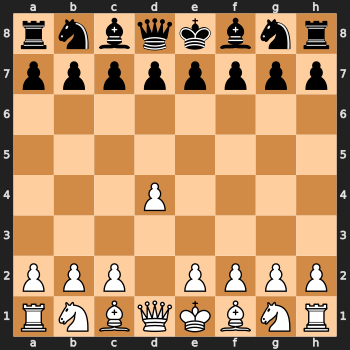

In [27]:
import chess.svg
from IPython.display import SVG, display

game_board = chess.Board()
SEARCH_MODE = False
ASSIST_MODE = "none"


def play(your_move=None):
    if your_move:
        game_board.push(game_board.parse_uci(your_move))
    move, metadata = choose_move(model, game_board, SEARCH_MODE, ASSIST_MODE, return_metadata=True)
    if move is not None:
        game_board.push(move)
        print(metadata)
    else:
        print("Terminal:", game_board.result(claim_draw=True))
    display(SVG(chess.svg.board(game_board, size=350)))

play()


In [30]:
sh("tar", "-czvf", "fly-chess.tar.gz", "fly-chess-v2", cwd=ROOT.parent)

$ tar -czvf fly-chess.tar.gz fly-chess-v2
fly-chess-v2/
fly-chess-v2/data/
fly-chess-v2/data/malecns-v1.0/
fly-chess-v2/data/malecns-v1.0/annotations.feather
fly-chess-v2/data/malecns-v1.0/edges.feather
fly-chess-v2/data/malecns-v1.0/neurotransmitters.feather
fly-chess-v2/data/connectome/
fly-chess-v2/data/connectome/full-graph.npz
fly-chess-v2/data/connectome/full-nodes.npz
fly-chess-v2/data/fly-chess/
fly-chess-v2/data/fly-chess/puzzles-full.csv
fly-chess-v2/data/fly-chess/positions-v2-full-1000000.json
fly-chess-v2/data/fly-chess/positions-v2-full-1000000.npz
fly-chess-v2/data/fly-chess/stockfish/
fly-chess-v2/data/fly-chess/stockfish/source.lock.json
fly-chess-v2/data/fly-chess/stockfish/stockfish
fly-chess-v2/runs/
fly-chess-v2/runs/fly-chess-v2/
fly-chess-v2/runs/fly-chess-v2/full-20260913-072724-45b8c335/
fly-chess-v2/runs/fly-chess-v2/full-20260913-072724-45b8c335/events.jsonl
fly-chess-v2/runs/fly-chess-v2/full-20260913-072724-45b8c335/main.pt
fly-chess-v2/runs/fly-chess-v2/fu

## Interpretation

Read `results.json` together with the immutable manifest, calibration, engine cache, game PGNs,
and training events. A completed smoke run verifies pipeline execution only. Full runs report
observed improvements, harms, or inconclusive comparisons without replacing unfavorable outcomes
with assertions. Resume with the same run ID and configuration; remove STOP before continuing.
